<a href="https://colab.research.google.com/github/kardam2806/Respiratory_conditions_ED_Notebook/blob/main/Tidy_resp_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Mounting drive is important to retain the dataset copy without the losing after runtime.
from google.colab import drive

# This will prompt for authorization
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Project data/Tidy_data.csv')


This step imports the file in the collab notebook. The file needs to be loaded in the folder first and its link needs to be copied to load the file

In [ ]:
import pandas as pd
df_wide = df.pivot_table(index='week_end',
                   columns=('age_group','condition'),
                   values='percent_visits',
                   aggfunc='sum')

Data wrangling: This step includes the conversion of dataframe from longitudinal data format to wider format for observing easily.
Using pivot_table as the data contains multiple duplicate entries in this dataset.

In [ ]:
df_wide.head()

age_group                       Adults 18-49                                 \
condition  Acute upper respiratory infection Bronchiolitis Bronchitis Croup   
week_end                                                                      
2023-10-07                               1.8           0.0        0.7   0.0   
2023-10-14                               1.9           0.0        0.8   0.0   
2023-10-21                               2.0           0.0        0.8   0.0   
2023-10-28                               2.0           0.0        0.9   0.0   
2023-11-04                               2.3           0.0        0.9   0.0   

age_group                                               \
condition  Laryngitis and tracheitis or supraglottitis   
week_end                                                 
2023-10-07                                         0.0   
2023-10-14                                         0.0   
2023-10-21                                         0.0   
2023-10-28                                         0.1   
2023-11-04                                         0.1   

age_group                                                                     \
condition  Other lower respiratory Pneumonia Respiratory distress or failure   
week_end                                                                       
2023-10-07                     0.0       0.7                             0.3   
2023-10-14                     0.0       0.7                             0.3   
2023-10-21                     0.0       0.8                             0.3   
2023-10-28                     0.0       0.8                             0.3   
2023-11-04                     0.0       0.8                             0.3   

age_group                                                        ...  \
condition  Sinus infection Sore throat (including strep throat)  ...   
week_end                                                         ...   
2023-10-07             0.3                                  1.9  ...   
2023-10-14             0.3                                  1.9  ...   
2023-10-21             0.4                                  2.0  ...   
2023-10-28             0.4                                  2.0  ...   
2023-11-04             0.4                                  2.1  ...   

age_group    Seniors 65+                   \
condition  Bronchiolitis Bronchitis Croup   
week_end                                    
2023-10-07           0.0        0.7   0.0   
2023-10-14           0.0        0.7   0.0   
2023-10-21           0.0        0.8   0.0   
2023-10-28           0.1        0.8   0.0   
2023-11-04           0.1        0.8   0.0   

age_group                                               \
condition  Laryngitis and tracheitis or supraglottitis   
week_end                                                 
2023-10-07                                         0.0   
2023-10-14                                         0.0   
2023-10-21                                         0.0   
2023-10-28                                         0.0   
2023-11-04                                         0.0   

age_group                                                                     \
condition  Other lower respiratory Pneumonia Respiratory distress or failure   
week_end                                                                       
2023-10-07                     0.0       3.5                             2.9   
2023-10-14                     0.0       3.6                             3.0   
2023-10-21                     0.0       3.6                             3.0   
2023-10-28                     0.0       3.6                             2.9   
2023-11-04                     0.0       3.7                             3.0   

age_group                                                                    
condition  Sinus infection Sore throat (including strep throat) Tonsillitis  
week_end                                                     

In [ ]:
df_wide.index = pd.to_datetime(df_wide.index)
df_monthly = df_wide.resample('ME').mean()
df_monthly.index = df_monthly.index.to_period('M')
print(df_monthly)


age_group                      Adults 18-49                                 \
condition Acute upper respiratory infection Bronchiolitis Bronchitis Croup   
week_end                                                                     
2023-10                               1.925         0.000   0.800000   0.0   
2023-11                               2.425         0.025   1.000000   0.0   
2023-12                               3.020         0.100   1.140000   0.0   
2024-01                               2.650         0.050   1.025000   0.0   
2024-02                               2.275         0.000   0.800000   0.0   
2024-03                               1.980         0.000   0.780000   0.0   
2024-04                               1.650         0.000   0.725000   0.0   
2024-05                               1.475         0.000   0.675000   0.0   
2024-06                               1.160         0.000   0.540000   0.0   
2024-07                               1.025         0.000   0.40

Dataset with time/date column is treated as string. Hence, it is therefore converted further using .dt version to further wrangle data into monthly format.


In [ ]:
df_wide = df_monthly.reset_index()
df_wide.head()

age_group week_end                      Adults 18-49                           \
condition          Acute upper respiratory infection Bronchiolitis Bronchitis   
0          2023-10                             1.925         0.000      0.800   
1          2023-11                             2.425         0.025      1.000   
2          2023-12                             3.020         0.100      1.140   
3          2024-01                             2.650         0.050      1.025   
4          2024-02                             2.275         0.000      0.800   

age_group                                                    \
condition Croup Laryngitis and tracheitis or supraglottitis   
0           0.0                                       0.025   
1           0.0                                       0.100   
2           0.0                                       0.100   
3           0.0                                       0.050   
4           0.0                                       0.050   

age_group                                                                    \
condition Other lower respiratory Pneumonia Respiratory distress or failure   
0                             0.0     0.750                           0.300   
1                             0.0     0.900                           0.300   
2                             0.0     1.080                           0.360   
3                             0.0     1.075                           0.375   
4                             0.0     0.975                           0.350   

age_group                  ...   Seniors 65+                   \
condition Sinus infection  ... Bronchiolitis Bronchitis Croup   
0                   0.350  ...         0.025      0.750   0.0   
1                   0.400  ...         0.100      0.900   0.0   
2                   0.480  ...         0.220      1.220   0.0   
3                   0.450  ...         0.200      1.150   0.0   
4                   0.425  ...         0.100      0.875   0.0   

age_group                                                                      \
condition Laryngitis and tracheitis or supraglottitis Other lower respiratory   
0                                                 0.0                     0.0   
1                                                 0.0                     0.0   
2                                                 0.0                     0.0   
3                                                 0.0                     0.0   
4                                                 0.0                     0.0   

age_group                                                            \
condition Pneumonia Respiratory distress or failure Sinus infection   
0             3.575                           2.950           0.200   
1             3.925                           3.125           0.200   
2             4.660                           3.600           0.240   
3             4.925                           3.750           0.250   
4             4.175                           3.400           0.225   

age_group                                                   
condition Sore throat (including strep throat) Tonsillitis  
0                                        0.300         0.0  
1                                        0.350         0.0  
2                                        0.440         0.0  
3                                        0.375         0.0  
4                                        0.350         0.0  

[5 rows x 78 columns]

In [ ]:
# 1. Start with your long-format data
df_long = df_wide.set_index('week_end').stack(level=[0,1]).reset_index()
df_long.columns = ['week_end', 'age_group', 'condition', 'value']

# 2. Pivot: Define what stays as rows (index) and what moves to columns
df_final = df_long.pivot(index=['age_group', 'week_end'],
                         columns='condition',
                         values='value')

# 3. Optional: Sort to keep age groups grouped together
df_final = df_final.sort_index()

df_final.head()

/tmp/ipykernel_684/4030323359.py:2: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df_long = df_wide.set_index('week_end').stack(level=[0,1]).reset_index()


condition              Acute upper respiratory infection  Bronchiolitis  \
age_group    week_end                                                     
Adults 18-49 2023-10                               1.925          0.000   
             2023-11                               2.425          0.025   
             2023-12                               3.020          0.100   
             2024-01                               2.650          0.050   
             2024-02                               2.275          0.000   

condition              Bronchitis  Croup  \
age_group    week_end                      
Adults 18-49 2023-10        0.800    0.0   
             2023-11        1.000    0.0   
             2023-12        1.140    0.0   
             2024-01        1.025    0.0   
             2024-02        0.800    0.0   

condition              Laryngitis and tracheitis or supraglottitis  \
age_group    week_end                                                
Adults 18-49 2023-10                                         0.025   
             2023-11                                         0.100   
             2023-12                                         0.100   
             2024-01                                         0.050   
             2024-02                                         0.050   

condition              Other lower respiratory  Pneumonia  \
age_group    week_end                                       
Adults 18-49 2023-10                       0.0      0.750   
             2023-11                       0.0      0.900   
             2023-12                       0.0      1.080   
             2024-01                       0.0      1.075   
             2024-02                       0.0      0.975   

condition              Respiratory distress or failure  Sinus infection  \
age_group    week_end                                                     
Adults 18-49 2023-10                             0.300            0.350   
             2023-11                             0.300            0.400   
             2023-12                             0.360            0.480   
             2024-01                             0.375            0.450   
             2024-02                             0.350            0.425   

condition              Sore throat (including strep throat)  Tonsillitis  
age_group    week_end                                                     
Adults 18-49 2023-10                                  1.950        0.200  
             2023-11                                  2.225        0.225  
             2023-12                                  2.460        0.240  
             2024-01                                  2.275        0.200  
             2024-02                                  2.325        0.225

- Data which needs to be displayed in columns vertically that needs to be under columns whereas the one wants to arrange as rows, it needs to be passed under index (index='age_group', 'week_end') this will display as above.

Summary statistic

In [ ]:
from google.colab import files

# Save DataFrame as Excel
df_final.to_excel('df_final.xlsx', index=True)

# Download
files.download('df_final.xlsx')

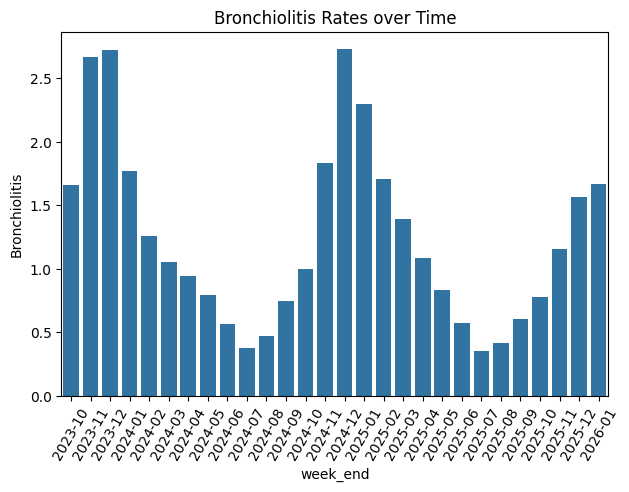

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use y='Bronchiolitis' with a Capital 'B'
sns.barplot(data=df_final,
            x='week_end',
            y='Bronchiolitis',
            errorbar=None)


plt.xticks(rotation=60)
plt.tight_layout()
plt.title("Bronchiolitis Rates over Time")
plt.show()


- If one condition vs time needs to displayed then above code works. While the need to display multiple disease vs time graph requires melting of data.

In [ ]:
# Checking the df gives a check on whether the change is as per desired expectation:
df_final.head()


condition              Acute upper respiratory infection  Bronchiolitis  \
age_group    week_end                                                     
Adults 18-49 2023-10                               1.925          0.000   
             2023-11                               2.425          0.025   
             2023-12                               3.020          0.100   
             2024-01                               2.650          0.050   
             2024-02                               2.275          0.000   

condition              Bronchitis  Croup  \
age_group    week_end                      
Adults 18-49 2023-10        0.800    0.0   
             2023-11        1.000    0.0   
             2023-12        1.140    0.0   
             2024-01        1.025    0.0   
             2024-02        0.800    0.0   

condition              Laryngitis and tracheitis or supraglottitis  \
age_group    week_end                                                
Adults 18-49 2023-10                                         0.025   
             2023-11                                         0.100   
             2023-12                                         0.100   
             2024-01                                         0.050   
             2024-02                                         0.050   

condition              Other lower respiratory  Pneumonia  \
age_group    week_end                                       
Adults 18-49 2023-10                       0.0      0.750   
             2023-11                       0.0      0.900   
             2023-12                       0.0      1.080   
             2024-01                       0.0      1.075   
             2024-02                       0.0      0.975   

condition              Respiratory distress or failure  Sinus infection  \
age_group    week_end                                                     
Adults 18-49 2023-10                             0.300            0.350   
             2023-11                             0.300            0.400   
             2023-12                             0.360            0.480   
             2024-01                             0.375            0.450   
             2024-02                             0.350            0.425   

condition              Sore throat (including strep throat)  Tonsillitis  
age_group    week_end                                                     
Adults 18-49 2023-10                                  1.950        0.200  
             2023-11                                  2.225        0.225  
             2023-12                                  2.460        0.240  
             2024-01                                  2.275        0.200  
             2024-02                                  2.325        0.225

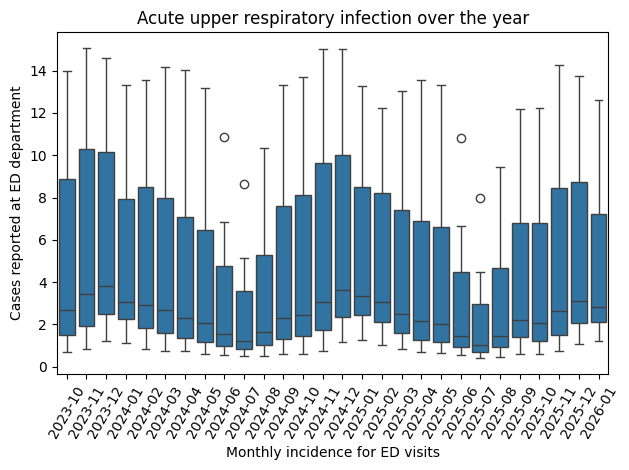

In [ ]:
from numpy import rot90
import seaborn as sns
import matplotlib.pyplot as plt
import math

# Plotting box plot gives idea about the median values and outliers in the df:
sns.boxplot(data=df_final,
            x='week_end',
            y='Acute upper respiratory infection')
plt.title('Acute upper respiratory infection over the year')
plt.xlabel('Monthly incidence for ED visits')
plt.ylabel('Cases reported at ED department')
# rotation allows better readability of text.
plt.tick_params(axis='x', rotation=60)

# Tight layout is very essential when one wants the edges defined for multiple graphs and to avoid graph text overlapping:
plt.tight_layout()
plt.show()




- Boxplot offers visualization opportunity to understand the data including outlier, but visually not backed by any numbers.
- In order to draw inference, statistical figure is extremely important which is calculated further.

In [ ]:
# To print count, mean, std, min, 25%, 50%(median), 75%, and max
print(df_final['Acute upper respiratory infection'].describe())

mean_val = df_final['Acute upper respiratory infection'].mean()
std_val = df_final['Acute upper respiratory infection'].std()
median_val = df_final['Acute upper respiratory infection'].median()
variance_val = df_final['Acute upper respiratory infection'].var()

print(f"Mean: {mean_val:.2f}")
print(f"Standard Deviation: {std_val:.2f}")
print(f"Median: {median_val:.2f}")
print(f"Variance: {variance_val:.2f}")

count    196.000000
mean       4.808656
std        4.542591
min        0.400000
25%        1.240000
50%        2.585000
75%        8.162500
max       15.075000
Name: Acute upper respiratory infection, dtype: float64
Mean: 4.81
Standard Deviation: 4.54
Median: 2.58
Variance: 20.64


- The difference between Mean(4.81) and Median(2.58) is large. This provides enough evidence to believe that there were hotspots in timeline when the  'Acute Upper Respiratory Infection' cases were reported higher than average in comparision to several weekends.

To plot for multiple conditions; dataframe needs to be melted and reorganised as required.

In [ ]:
# checking how the dataframe looks like to proceed the melting as required:
df_final.head()

condition              Acute upper respiratory infection  Bronchiolitis  \
age_group    week_end                                                     
Adults 18-49 2023-10                               1.925          0.000   
             2023-11                               2.425          0.025   
             2023-12                               3.020          0.100   
             2024-01                               2.650          0.050   
             2024-02                               2.275          0.000   

condition              Bronchitis  Croup  \
age_group    week_end                      
Adults 18-49 2023-10        0.800    0.0   
             2023-11        1.000    0.0   
             2023-12        1.140    0.0   
             2024-01        1.025    0.0   
             2024-02        0.800    0.0   

condition              Laryngitis and tracheitis or supraglottitis  \
age_group    week_end                                                
Adults 18-49 2023-10                                         0.025   
             2023-11                                         0.100   
             2023-12                                         0.100   
             2024-01                                         0.050   
             2024-02                                         0.050   

condition              Other lower respiratory  Pneumonia  \
age_group    week_end                                       
Adults 18-49 2023-10                       0.0      0.750   
             2023-11                       0.0      0.900   
             2023-12                       0.0      1.080   
             2024-01                       0.0      1.075   
             2024-02                       0.0      0.975   

condition              Respiratory distress or failure  Sinus infection  \
age_group    week_end                                                     
Adults 18-49 2023-10                             0.300            0.350   
             2023-11                             0.300            0.400   
             2023-12                             0.360            0.480   
             2024-01                             0.375            0.450   
             2024-02                             0.350            0.425   

condition              Sore throat (including strep throat)  Tonsillitis  
age_group    week_end                                                     
Adults 18-49 2023-10                                  1.950        0.200  
             2023-11                                  2.225        0.225  
             2023-12                                  2.460        0.240  
             2024-01                                  2.275        0.200  
             2024-02                                  2.325        0.225

,week_end,Condition,Rate
0,2023-10,Acute upper respiratory infection,1.925
1,2023-11,Acute upper respiratory infection,2.425
2,2023-12,Acute upper respiratory infection,3.020
3,2024-01,Acute upper respiratory infection,2.650
4,2024-02,Acute upper respiratory infection,2.275


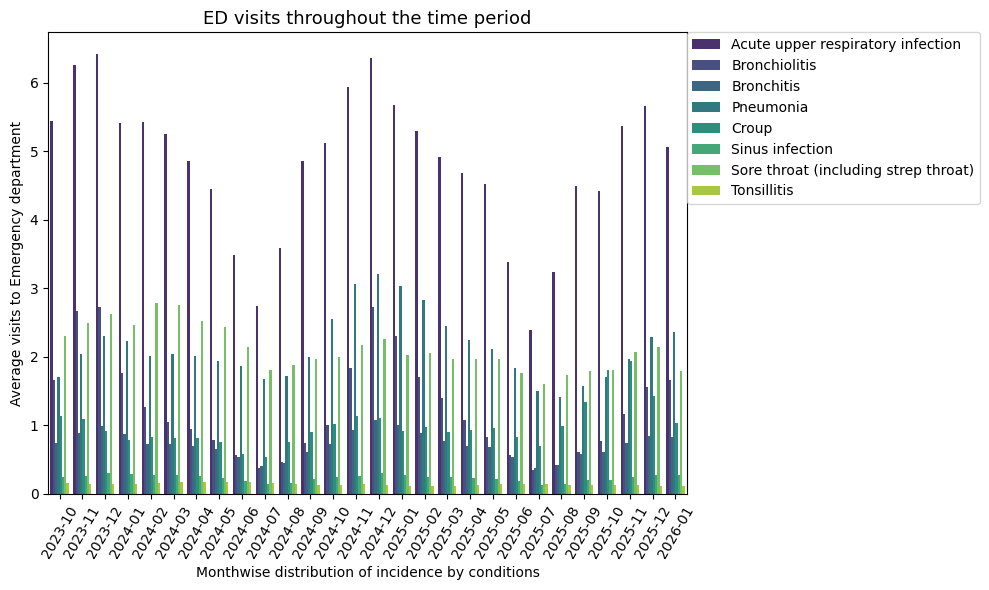

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("df_final.xlsx")
# when using processed data, use the file generated and also put within double quotes.

# 2. Identify the condition columns you want to plot and the strip function to ignore spaces which lead to keyword error.
# Stripping would remove the error that could be because of spacing and other.
df.columns = df.columns.str.strip()
condition_cols = ['Acute upper respiratory infection','Bronchiolitis', 'Bronchitis',
    'Pneumonia', 'Croup', 'Sinus infection',
    'Sore throat (including strep throat)', 'Tonsillitis']

# 3 Melt the data into long format for plotting:

df_melted = pd.melt(df, id_vars=['week_end'],
                    value_vars=condition_cols,
                    var_name='Condition',
                    value_name='Rate')


# plotting the bar chart with multiple conditions:
plt.figure(figsize=(10,6))
sns.barplot(df_melted, x= 'week_end',
                y= 'Rate',
                hue='Condition',
                errorbar=None,
                palette='viridis',
                )

# Defining the legend will anchor the box inside or outside the graph borders.
plt.legend(bbox_to_anchor=(1.0,1.0), loc='upper left', borderaxespad=0, fontsize='10')
plt.ylabel('Average visits to Emergency department', fontsize = 10)
plt.xlabel('Monthwise distribution of incidence by conditions', fontsize = 10)
plt.title('ED visits throughout the time period', fontsize = 13)
plt.xticks(rotation=60)
plt.tight_layout()
df_melted.head()

In [ ]:
# Get a custom list of stats for each illness
custom_stats = df_melted.groupby('Condition')['Rate'].agg(['mean', 'median', 'std', 'var'])

print(custom_stats)

                                          mean  median       std        var
Condition                                                                  
Acute upper respiratory infection     4.808656  2.5850  4.542591  20.635132
Bronchiolitis                         1.250136  0.1500  2.498740   6.243703
Bronchitis                            0.715408  0.6750  0.265625   0.070557
Croup                                 0.998002  0.2000  1.468228   2.155694
Pneumonia                             2.130638  1.8900  1.070966   1.146969
Sinus infection                       0.232321  0.2200  0.108420   0.011755
Sore throat (including strep throat)  2.116080  1.5675  1.933393   3.738009
Tonsillitis                           0.139617  0.1000  0.126365   0.015968


Summary statistic:
1. Acute upper respiratory infections dominate ED visits with a mean of 4.81, showing significant volatility and outbreak patterns due to high variance of 20.64.
2. In contrast, conditions like sinus infections and Tonsilitis remain highly stable and predictable, maintaining consistently low incidence rates throughout the period.

/tmp/ipykernel_684/3114684140.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


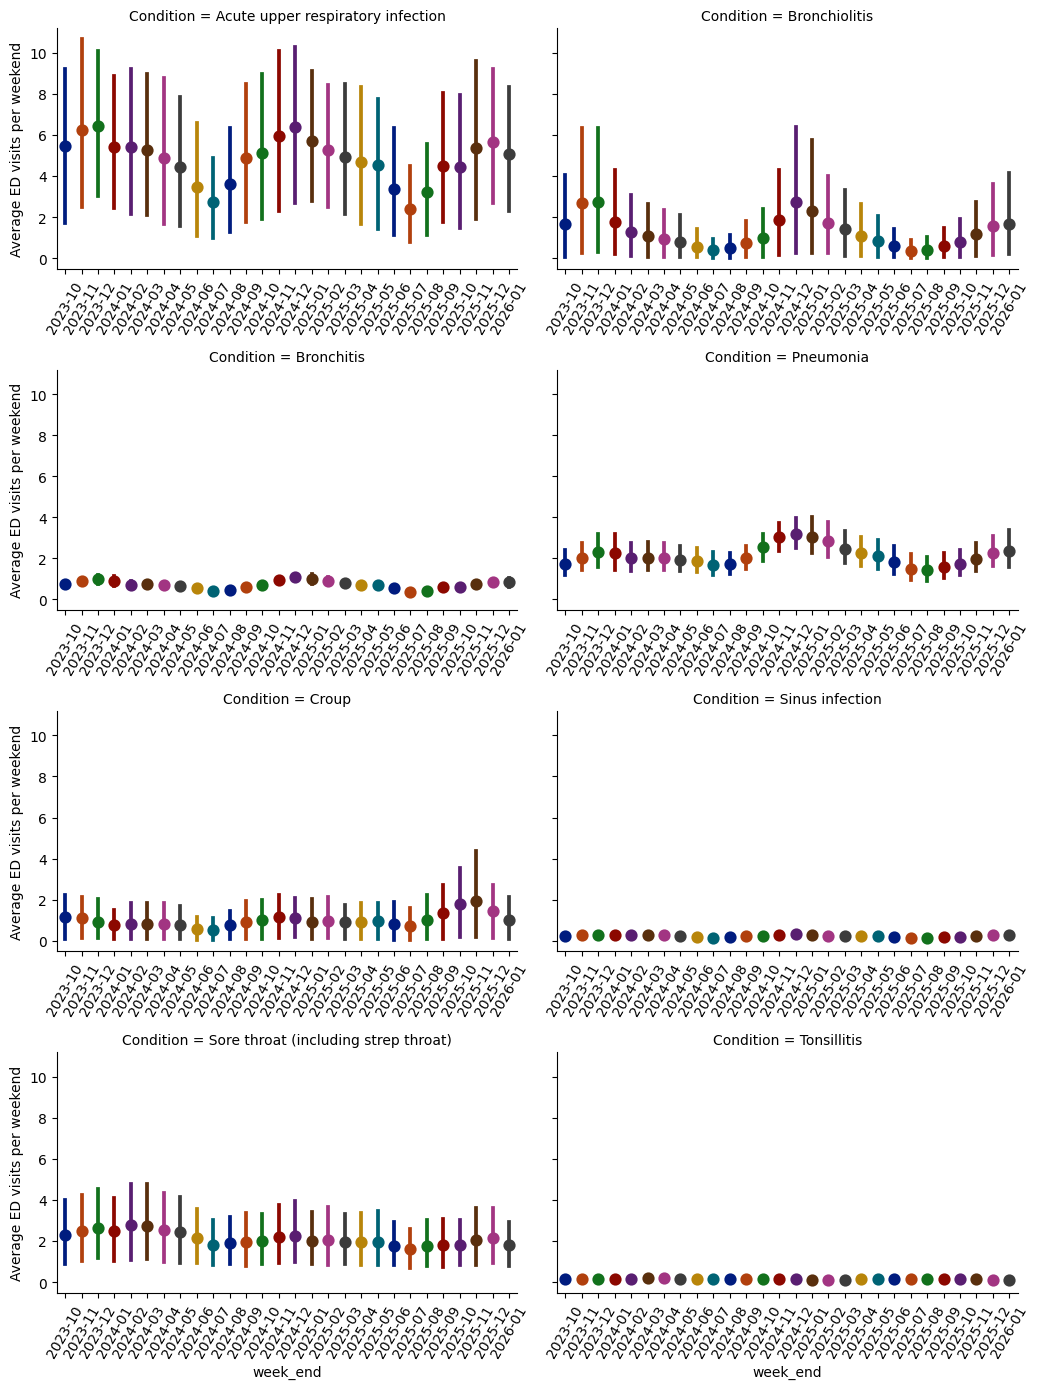

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("df_final.xlsx")
# when using processed data, use the file generated and also put within double quotes.

# 2. Identify the condition columns you want to plot and the strip function to ignore spaces which lead to keyword error.
df.columns = df.columns.str.strip()
condition_cols = ['Acute upper respiratory infection','Bronchiolitis', 'Bronchitis',
    'Pneumonia', 'Croup', 'Sinus infection',
    'Sore throat (including strep throat)', 'Tonsillitis']

# 3 Melt the data into long format for plotting:

df_melted = pd.melt(df, id_vars=['week_end'],
                    value_vars=condition_cols,
                    var_name='Condition',
                    value_name='Average ED visits per weekend')

g = sns.catplot(
    data=df_melted,
    x='week_end',
    y='Average ED visits per weekend',
    col='Condition',
    kind='point',
    col_wrap=2,
    height=3.5,
    aspect=1.5,
    palette='dark',
    sharex=False
)

g.set_xticklabels(rotation=60)
g.tight_layout()

1. The facet plots further backs the claim to support the findings of statistics.
2. Additionally, these plots provides evidence of seasonal outbreak of Bronchiolitis and Pneumonia by the way pattern in its incidence.

In [ ]:
# Converting the data to datetime format allows interconversion of data to either year or months:
df['week_end'] = pd.to_datetime(df_melted['week_end'], errors='coerce')
df.head()

df['Year'] = df['week_end'].dt.year
df.head()

df_clean = df.dropna(subset=['week_end']).copy()
df_clean.head()


,age_group,week_end,Acute upper respiratory infection,Bronchiolitis,Bronchitis,Croup,Laryngitis and tracheitis or supraglottitis,Other lower respiratory,Pneumonia,Respiratory distress or failure,Sinus infection,Sore throat (including strep throat),Tonsillitis,Year
0,Adults 18-49,2023-10-01,1.925,0.000,0.800,0.0,0.025,0.0,0.750,0.300,0.350,1.950,0.200,2023
1,NaN,2023-11-01,2.425,0.025,1.000,0.0,0.100,0.0,0.900,0.300,0.400,2.225,0.225,2023
2,NaN,2023-12-01,3.020,0.100,1.140,0.0,0.100,0.0,1.080,0.360,0.480,2.460,0.240,2023
3,NaN,2024-01-01,2.650,0.050,1.025,0.0,0.050,0.0,1.075,0.375,0.450,2.275,0.200,2024
4,NaN,2024-02-01,2.275,0.000,0.800,0.0,0.050,0.0,0.975,0.350,0.425,2.325,0.225,2024


Plotting line graph to analyse how the "Wave" looked like?


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Creating a list that could be passed to draw trend further:
condition_cols = ['Acute upper respiratory infection','Bronchiolitis', 'Bronchitis',
    'Pneumonia', 'Croup', 'Sinus infection',
    'Sore throat (including strep throat)', 'Tonsillitis']

# Melting data rearranges the columns into row format by id vars argument and assigns the value in a seperate column using value_var argument.
df_melted_yearly = pd.melt(df_clean, id_vars='Year',
                    value_vars=condition_cols,
                    var_name='Condition',
                    value_name='Rate')
df_melted_yearly.head()



,Year,Condition,Rate
0,2023,Acute upper respiratory infection,1.925
1,2023,Acute upper respiratory infection,2.425
2,2023,Acute upper respiratory infection,3.020
3,2024,Acute upper respiratory infection,2.650
4,2024,Acute upper respiratory infection,2.275


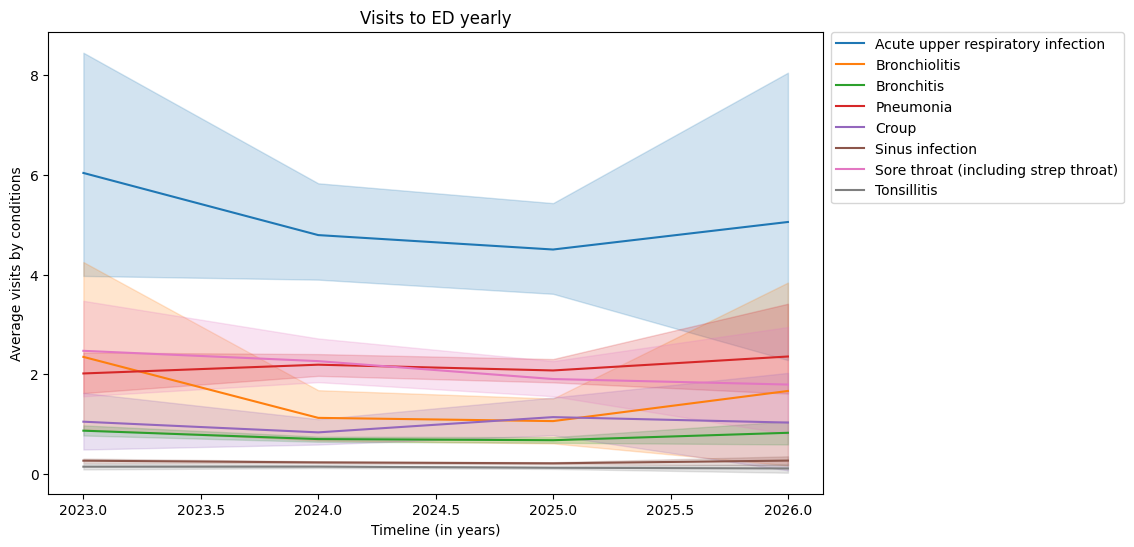

In [ ]:
# Plotting the line graph for yearwise prevalence:
plt.figure(figsize=(10,6))
sns.lineplot(df_melted_yearly,
             x='Year',
             y='Rate',
             hue='Condition')

# Adjusting the legend box outside the graph:
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0, fontsize='10')

# Adding labels to x and y axis:
plt.ylabel('Average visits by conditions', fontsize = 10)
plt.xlabel('Timeline (in years)', fontsize = 10)
plt.title('Visits to ED yearly')
plt.show()

Progress note:
Problems addressed:
1. What was the "Disease of the Year"? - Acute Upper Respiratory Infection
2. What did the "Wave" look like? - Fairly stable with peak timezones(month) and three out of all diseases shows upward trend at during last year in dataframe.
3. What was the most common illness overall? 1. Acute Upper Respiratory Infection

Methods used:
1. Histogram to check indicence rate of specific disease.
2. Barplot to determine median range of visits for a particular disease.
3. Catplot to characterize condition wise ED visits throughout the period to define the hotspot timezones when the conditions are at peak.
4. Line chart to analyze the pattern of incidence that lead to x number of visits to Emergency department during the time period.


Aim: To analyze which disease was the 'Disease of the year'?

In [ ]:
# 1. Group by Year and Condition to find the average Rate
yearly_rank = df_melted_yearly.groupby(['Year', 'Condition'])['Rate'].mean().reset_index()

# 2. Sorting by rate and picking the highest one
disease_of_the_year = yearly_rank.sort_values(['Year', 'Rate'], ascending=[True, False]).groupby('Year').head(1).reset_index(drop=True)

print("--- Disease of the Year ---")
print(disease_of_the_year)

--- Disease of the Year ---
   Year                          Condition      Rate
0  2023  Acute upper respiratory infection  6.034762
1  2024  Acute upper respiratory infection  4.789762
2  2025  Acute upper respiratory infection  4.500714
3  2026  Acute upper respiratory infection  5.052381


In [ ]:
# Grouping the data according to age to see which group is most affected:

#cleaning the data and averaging the mean groupwise considering numeric value only:
df_age = df_clean.groupby(['age_group','week_end']).mean(numeric_only=True).reset_index()

df_age.head()

,age_group,week_end,Acute upper respiratory infection,Bronchiolitis,Bronchitis,Croup,Laryngitis and tracheitis or supraglottitis,Other lower respiratory,Pneumonia,Respiratory distress or failure,Sinus infection,Sore throat (including strep throat),Tonsillitis,Year
0,Adults 18-49,2023-10-01,1.925,0.000,0.800,0.000,0.025,0.000,0.750,0.300,0.35,1.950,0.200,2023.0
1,Adults 50-64,2023-10-01,1.100,0.000,0.950,0.000,0.000,0.000,1.875,1.400,0.30,0.600,0.000,2023.0
2,Infants 0-1,2023-10-01,13.975,8.450,0.550,3.375,0.000,0.075,1.350,0.925,0.10,0.875,0.075,2023.0
3,Kids 2-4,2023-10-01,12.250,2.450,0.775,3.725,0.000,0.100,1.875,0.450,0.20,4.150,0.250,2023.0
4,Kids 5-17,2023-10-01,5.475,0.225,0.550,0.575,0.000,0.000,0.875,0.200,0.25,6.350,0.400,2023.0


Aim: To analyze which group was hit the hardest:

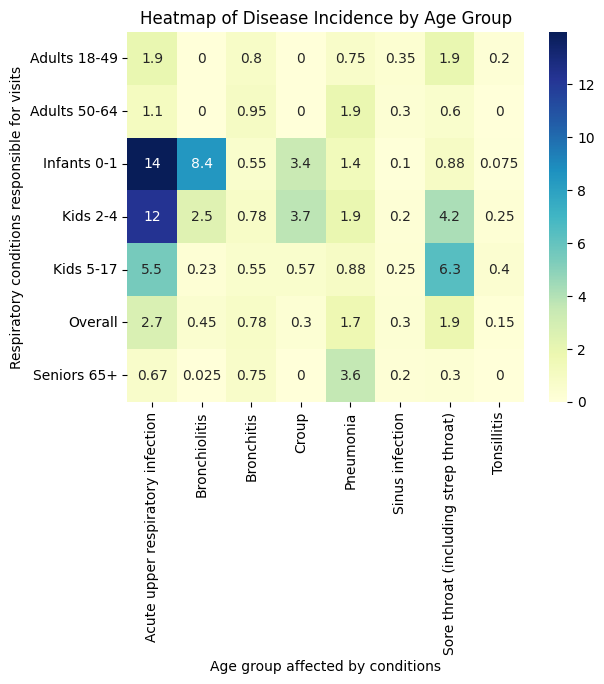

In [ ]:
# Analyzing the groupwise affected trend:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Melting the data to bring condition into single column:
condition_cols = ['Acute upper respiratory infection','Bronchiolitis', 'Bronchitis',
    'Pneumonia', 'Croup', 'Sinus infection',
    'Sore throat (including strep throat)', 'Tonsillitis']

df_melted_groupwise = pd.melt(df_age, id_vars=['age_group', 'Year'],
                              value_vars= condition_cols,
                              var_name='Condition',
                              value_name='Rate')
df_melted_groupwise.head()

if 'Year' in df_melted_groupwise.columns:
    df_numeric = df_melted_groupwise.drop(columns=['Year'])

# To generate heatmap and groupwise comparision, matrix conversion is important:
df_matrix = df_melted_groupwise.pivot_table(index='age_group',
                                            columns='Condition',
                                            values='Rate',
                                            aggfunc='mean')
df_matrix.head()

# Now plot the pivot table
sns.heatmap(df_matrix, annot=True, cmap='YlGnBu')
plt.title('Heatmap of Disease Incidence by Age Group')
plt.ylabel('Respiratory conditions responsible for visits', fontsize=10)
plt.xlabel('Age group affected by conditions', fontsize = 10)
plt.xticks(rotation=90)
plt.show()
#



* The dark blue 8.4 for Infants 0-1 means they have a significantly higher rate
of ED visits for Bronchiolitis than any other group, as their smaller airways make this infection much more severe. Since the rate is 0 for adults, it confirms this is almost exclusively a pediatric emergency issue that rarely affects older populations.